In [1]:
from pathlib import Path

import duckdb

import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt

import mmlib

# Veículos interessantes - antigo
- 0: Resultado do map matching é quase perfeito
- 1: Resultado do map matching é muito bom
- 10: Resultado do map matching sofre de desvio desnecessário
- 33: Resultado do map matching sofre de desvio desnecessário extremo
- 30: Quase perfeito
- 1000: Muito ruim, um dos piores resultados

## Veículos interessantes - novo

- 31: Map matching perfeito
- 768: Bom resultado de map matching
- 43: Quase perfeito
- 1001: Quase perfeito
- 1450: Perfeito
- 1712: Quase perfeito
- 567: Sofre de desvio desnecessário extremo
- 296: Resultado perfeito
- 124: Desvio desnecessário
- 902: Desvio desnecessário extremo
- 38: Muito ruim, um dos piores resultados
- 36: Resultado perfeito    
- 34: Erro superior a 600%
- 1754: Resultado perfeito

In [2]:
ROOT_PATH = Path("..").resolve().absolute()
OSRM_BASE_URL = "http://localhost:5000"
VEHICLE_ID = 296
SAMPLE_RATE: int | None = 1  # seconds

In [3]:
GROUND_TRUTH_PATH = (
    ROOT_PATH
    / "sumo/simulations/ohare-chicago-junctionless/output/fcd_resolved_2.parquet"
)
NOISE_PARQUET = (
    ROOT_PATH / "sumo/simulations/ohare-chicago-junctionless/output/fcd_noisy_2.parquet"
)
NETWORK_PATH = ROOT_PATH / "networks/filtered/ohare-filtered.osm.xml"

In [4]:
type Coordinate = tuple[float, float]  # (latitude, longitude)

In [5]:
duckdb.query(f"SELECT COUNT(DISTINCT vehicle_id) FROM '{GROUND_TRUTH_PATH}'")

┌────────────────────────────┐
│ count(DISTINCT vehicle_id) │
│           int64            │
├────────────────────────────┤
│                       1759 │
└────────────────────────────┘

In [6]:
def load_road_dataset(path: Path, sample_rate: float | None = None) -> pd.DataFrame:
    df = duckdb.query(
        f"""                
        SELECT lon, lat, TO_TIMESTAMP(time) AS timestamp, edge_id, reversed, raw_lane_id, mapped_lane_id
        FROM '{path}'
        WHERE vehicle_id = {VEHICLE_ID}
        ORDER BY time ASC
        """
    ).to_df()

    if sample_rate is not None:
        df = df.resample(f"{sample_rate:.2f}s", on="timestamp").first().reset_index()

    return df

In [7]:
gt_df = load_road_dataset(GROUND_TRUTH_PATH)
gt_df

,lon,lat,timestamp,edge_id,reversed,raw_lane_id,mapped_lane_id
0,-87.882982,41.979453,1969-12-31 21:10:58-03:00,981220946,False,981220946_0,981220946_0
1,-87.882988,41.979450,1969-12-31 21:10:58.500000-03:00,981220946,False,981220946_0,981220946_0
2,-87.882999,41.979446,1969-12-31 21:10:59-03:00,981220946,False,981220946_0,981220946_0
3,-87.883014,41.979439,1969-12-31 21:10:59.500000-03:00,981220946,False,981220946_0,981220946_0
4,-87.883036,41.979430,1969-12-31 21:11:00-03:00,981220946,False,981220946_0,981220946_0
...,...,...,...,...,...,...,...
934,-87.883225,41.994983,1969-12-31 21:18:34-03:00,1359831442,False,1359831442_1,1359831442_1
935,-87.883294,41.994983,1969-12-31 21:18:34.500000-03:00,1359831442,False,1359831442_1,1359831442_1
936,-87.883368,41.994983,1969-12-31 21:18:35-03:00,1359831442,False,1359831442_1,1359831442_1
937,-87.883450,41.994983,1969-12-31 21:18:35.500000-03:00,1359831442,False,1359831442_1,1359831442_1


In [8]:
noisy_df = load_road_dataset(NOISE_PARQUET, sample_rate=SAMPLE_RATE)
noisy_df

,timestamp,lon,lat,edge_id,reversed,raw_lane_id,mapped_lane_id
0,1969-12-31 21:10:58-03:00,-87.883038,41.979491,981220946,False,981220946_0,981220946_0
1,1969-12-31 21:10:59-03:00,-87.883010,41.979428,981220946,False,981220946_0,981220946_0
2,1969-12-31 21:11:00-03:00,-87.883124,41.979345,981220946,False,981220946_0,981220946_0
3,1969-12-31 21:11:01-03:00,-87.883044,41.979379,981220946,False,981220946_0,981220946_0
4,1969-12-31 21:11:02-03:00,-87.883067,41.979402,981220946,False,981220946_0,981220946_0
...,...,...,...,...,...,...,...
454,1969-12-31 21:18:32-03:00,-87.883018,41.995006,1359831442,False,1359831442_1,1359831442_1
455,1969-12-31 21:18:33-03:00,-87.883023,41.994995,1359831442,False,1359831442_1,1359831442_1
456,1969-12-31 21:18:34-03:00,-87.883269,41.995015,1359831442,False,1359831442_1,1359831442_1
457,1969-12-31 21:18:35-03:00,-87.883433,41.994961,1359831442,False,1359831442_1,1359831442_1


In [9]:
def df_to_gps_coordinates(df: pd.DataFrame):
    if SAMPLE_RATE is not None:
        df = df.resample(f"{SAMPLE_RATE:.2f}s", on="timestamp").first().reset_index()
    return df[["lat", "lon", "timestamp"]].to_records(index=False).tolist()


def df_to_coordinates(df: pd.DataFrame):
    return (
        df.sort_values(by="timestamp")[["lat", "lon"]].to_records(index=False).tolist()
    )


def df_to_edge_ids(df: pd.DataFrame):
    return df.sort_values(by="timestamp")["edge_id"].tolist()

In [10]:
gt_gps_measurements = df_to_gps_coordinates(gt_df)
gt_coordinates = df_to_coordinates(gt_df)
gt_edge_ids = df_to_edge_ids(gt_df)

print("GROUND TRUTH: ", len(gt_coordinates), "points")
print("first 3 points:", gt_coordinates[:3])
print("first 3 edge ids:", gt_edge_ids[:3])
print("fist 3 coordinates:", gt_gps_measurements[:3])

GROUND TRUTH:  939 points
first 3 points: [(41.97945258975684, -87.88298216131712), (41.97945026101397, -87.88298779219079), (41.97944579412601, -87.8829985930719)]
first 3 edge ids: ['981220946', '981220946', '981220946']
fist 3 coordinates: [(41.97945258975684, -87.88298216131712, Timestamp('1969-12-31 21:10:58-0300', tz='America/Fortaleza')), (41.97944579412601, -87.8829985930719, Timestamp('1969-12-31 21:10:59-0300', tz='America/Fortaleza')), (41.97943035271662, -87.88303593018266, Timestamp('1969-12-31 21:11:00-0300', tz='America/Fortaleza'))]


In [11]:
noisy_gps_measurements = df_to_gps_coordinates(noisy_df)
noisy_coordinates = df_to_coordinates(noisy_df)
noisy_edge_ids = df_to_edge_ids(noisy_df)

print("NOISY: ", len(noisy_coordinates), "points")
print("first 3 points:", noisy_coordinates[:3])
print("first 3 edge ids:", noisy_edge_ids[:3])
print("first 3 coordinates:", noisy_gps_measurements[:3])

NOISY:  459 points
first 3 points: [(41.9794905590133, -87.8830381420049), (41.97942841696581, -87.8830104032357), (41.97934527303213, -87.88312413211915)]
first 3 edge ids: ['981220946', '981220946', '981220946']
first 3 coordinates: [(41.9794905590133, -87.8830381420049, Timestamp('1969-12-31 21:10:58-0300', tz='America/Fortaleza')), (41.97942841696581, -87.8830104032357, Timestamp('1969-12-31 21:10:59-0300', tz='America/Fortaleza')), (41.97934527303213, -87.88312413211915, Timestamp('1969-12-31 21:11:00-0300', tz='America/Fortaleza'))]


In [12]:
from mmlib.types import GPSPoint

gps_points =[
    GPSPoint(lat=lat, lon=lon, time=timestamp)
    for lat, lon, timestamp in noisy_gps_measurements
]

In [13]:
osrm_matcher = mmlib.osrm_matcher(OSRM_BASE_URL)
match_result = osrm_matcher.match(gps_points)
match_result.plot()

In [14]:
len(noisy_gps_measurements), len(match_result.matched_points)

(459, 612)

In [15]:
ground_truth_edges = set(gt_edge_ids)
matched_edges = set(match_result.edge_ids)
(
    len(matched_edges),
    len(ground_truth_edges),
    len(matched_edges & ground_truth_edges),
    len(matched_edges ^ ground_truth_edges),
)

(58, 52, 51, 8)

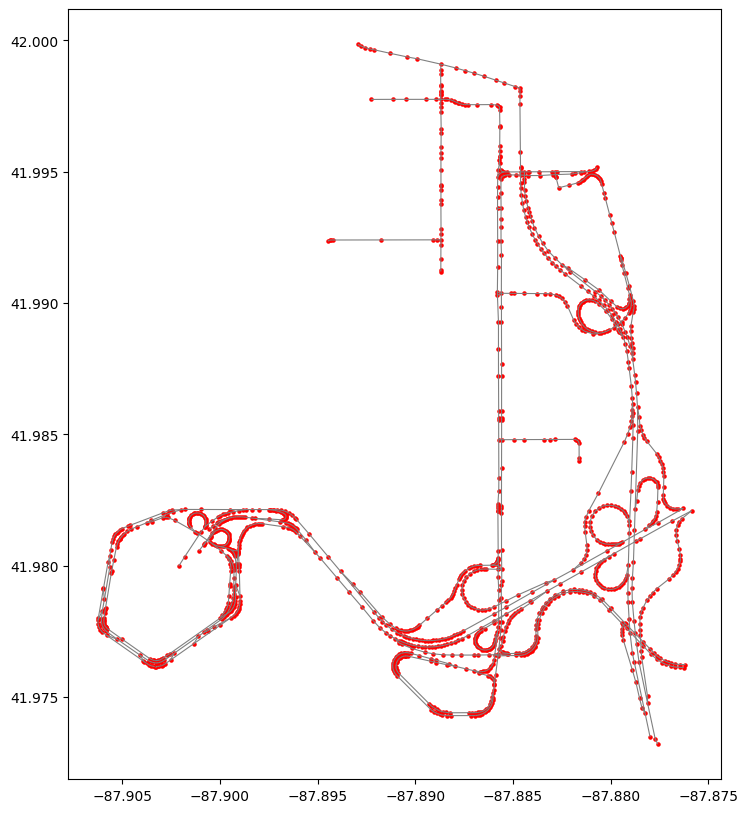

In [16]:
G = ox.load_graphml(ROOT_PATH / "networks/graphml/ohare_network.graphml")

nodes, edges = ox.graph_to_gdfs(G)

fig, ax = plt.subplots(figsize=(10, 10))

edges.plot(ax=ax, linewidth=0.8, color="gray")
nodes.plot(ax=ax, markersize=5, color="red")

plt.show()

In [17]:
match_result.plot_on_graph(G, ground_truth_edge_ids=gt_edge_ids)

In [18]:
match_result.plot_on_folium(G, ground_truth_edge_ids=gt_edge_ids)

In [19]:
import asyncio
import time
from mmlib.matcher.online import batches_matcher, fsw_matcher
from mmlib.types import GPSPoint


gps_points = [
    GPSPoint(lat=lat, lon=lon, time=timestamp)
    for lat, lon, timestamp in noisy_gps_measurements
]


async def emit_points(points: list[GPSPoint]):
    for point in points:
        yield point
        await asyncio.sleep(0.1)


# me
fsw_matcher = fsw_matcher(
    osrm_matcher, window_size=20, lookahead_depth=6, emit_every=5
)
batches_matcher = batches_matcher(osrm_matcher, batch_size=30)

async with fsw_matcher as matcher:
    start = time.time()
    o_result = await matcher.match_batch(gps_points)
    print(f"Total time to match: {time.time() - start:.2f} seconds")
    o_result.plot(zoom=12)

Total time to match: 1.88 seconds


In [20]:
o_result.plot_on_graph(G, ground_truth_edge_ids=gt_edge_ids)

In [21]:
o_result.plot_on_folium(G, ground_truth_edge_ids=gt_edge_ids)